# Bistable diaphragm metafluid: 1D simulation

Discrete equation of motion for diaphragm $n$:

$$ m \, \ddot u_n = A \, p_0 v_0 \left[ \frac{1}{v_{n-1}} - \frac{1}{v_n} \right] - f(u_n) - \alpha \dot u_n $$

where $v_n = v_0 + A(u_n - u_{n+1})$ is the volume of the segment between diaphragm $n$ and $n+1$, gas pressures follow Boyle's law $p_n v_n = p_0 v_0$, and the on-site bistable force is

$$ f(u) = u^3 - a^2 u + \delta . $$

A small damping term $\alpha \dot u_n$ has been added for numerical stability — without it the snapping events drive the system unstable.

Boundary conditions: $u_0$ held fixed at $u_{\rm lo}$ (low-energy, trigger end) and $u_{N-1}$ held fixed at $u_{\rm hi}$ (high-energy).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

N = 120          # number of diaphragms

# bistable potential f(u) = u^3 - a^2*u + delta
a2    = 0.09     # = c^2 from magnet system
delta = 0.009   # asymmetry — drives high-energy to low-energy transition
                 # bistability requires |delta| < 2*a^3/(3*sqrt(3)) ~ 0.0104
                 # no propagation when = 0, good smoke test

# diaphragm and fluid parameters
m     = 1.0      # diaphragm mass
A     = 1.0      # cross-sectional area (matched to Arrieta force prefactor)
p0    = 1.0      # reference pressure
v0    = 1.0      # reference segment volume (matched to Arrieta lattice spacing d=1)
alpha = 0.05     # damping (matched to Arrieta)

# absorbing sponge layers at boundaries
n_sponge = 10
damp_max = 4.0

# trigger setup
n_trigger = 5    # number of diaphragms held fixed at the low-energy end

# time stepping
dt = 1e-4
T  = 130.0
steps = int(T / dt)
save_every = 500

# Find well positions (roots of f(u) = 0)

roots      = np.roots([1, 0, -a2, delta])
real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
u_lo, u_mid, u_hi = real_roots[0], real_roots[1], real_roots[2]

def psi(u):
    # potential, integral of f(u)
    return u**4/4 - a2*u**2/2 + delta*u

print(f"Well positions:")
print(f"  u_lo  = {u_lo:.4f}   (stable, low energy: psi = {psi(u_lo):.6f})")
print(f"  u_mid = {u_mid:.4f}   (unstable)")
print(f"  u_hi  = {u_hi:.4f}   (stable, high energy: psi = {psi(u_hi):.6f})")
print(f"  Energy difference psi(u_hi) - psi(u_lo) = {psi(u_hi) - psi(u_lo):.6f}")

Well positions:
  u_lo  = -0.3411   (stable, low energy: psi = -0.004921)
  u_mid = 0.1185   (unstable)
  u_hi  = 0.2227   (stable, high energy: psi = 0.000387)
  Energy difference psi(u_hi) - psi(u_lo) = 0.005309


In [2]:
# Forces

# build damping array with sponge layers
damp = np.ones(N) * alpha
for i in range(n_sponge):
    strength = damp_max * ((n_sponge - i) / n_sponge) ** 2
    damp[i]         += strength
    damp[N - 1 - i] += strength


def f_bistable(u):
    # on-site bistable restoring force
    return u**3 - a2*u + delta


def pressure_force(u):
    # net gas pressure force on each diaphragm via Boyle's law
    # segment n volume: v_n = v_0 + A*(u_n - u_{n+1})
    # segment n pressure: p_n = p_0 * v_0 / v_n
    # force on diaphragm n (interior): F_n = A * (p_{n-1} - p_n)
    F = np.zeros_like(u)
    seg_vols  = v0 + A * (u[1:] - u[:-1])
    seg_vols  = np.maximum(seg_vols, 1e-6)         # clamp to avoid singularity
    pressures = p0 * v0 / seg_vols
    F[1:-1]   = A * (pressures[:-1] - pressures[1:])
    return F


def acceleration(u, v):
    # m*u_tt = pressure force - bistable force - damping*velocity
    return (pressure_force(u) - f_bistable(u) - damp * v) / m

In [3]:
# Initial conditions and time stepping (velocity Verlet)

# all diaphragms in high-energy well, first n_trigger snapped to low-energy well
u = np.ones(N) * u_hi
u[:n_trigger] = u_lo
v = np.zeros(N)

history = []
a = acceleration(u, v)

for step in range(steps):

    # velocity Verlet
    u += v * dt + 0.5 * a * dt**2

    # fix boundaries: trigger held at u_lo, right end held at u_hi
    u[:n_trigger] = u_lo
    u[-1]         = u_hi
    v[:n_trigger] = 0.0
    v[-1]         = 0.0

    a_new = acceleration(u, v)
    v    += 0.5 * (a + a_new) * dt
    a     = a_new

    if step % save_every == 0:
        history.append(u.copy())

    if step % 200000 == 0:
        mid       = 0.5 * (u_lo + u_hi)
        front     = np.where(u < mid)[0]
        front_pos = front[-1] if len(front) else 0
        print(f"  step: {step}  max u: {np.max(u):.4f}  min u: {np.min(u):.4f}  front: {front_pos}")

history = np.array(history)

  step: 0  max u: 0.2227  min u: -0.3411  front: 4
  step: 200000  max u: 0.2227  min u: -0.3894  front: 19
  step: 400000  max u: 0.2227  min u: -0.3975  front: 37
  step: 600000  max u: 0.2227  min u: -0.3911  front: 55
  step: 800000  max u: 0.2227  min u: -0.3752  front: 73
  step: 1000000  max u: 0.2227  min u: -0.3769  front: 91
  step: 1200000  max u: 0.2227  min u: -0.3761  front: 109


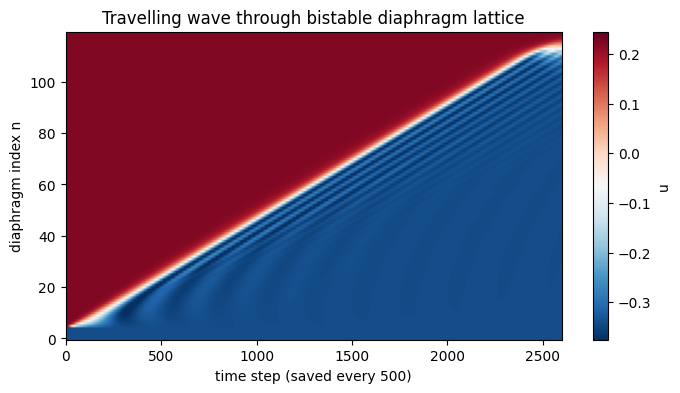

In [4]:
# Heatmap of u_n vs (time, position)

plt.figure(figsize=(8, 4))
plt.imshow(history.T, aspect='auto', origin='lower',
           vmin=u_lo*1.1, vmax=u_hi*1.1, cmap='RdBu_r')
plt.xlabel("time step (saved every {})".format(save_every))
plt.ylabel("diaphragm index n")
plt.title("Travelling wave through bistable diaphragm lattice")
plt.colorbar(label='u')
plt.show()

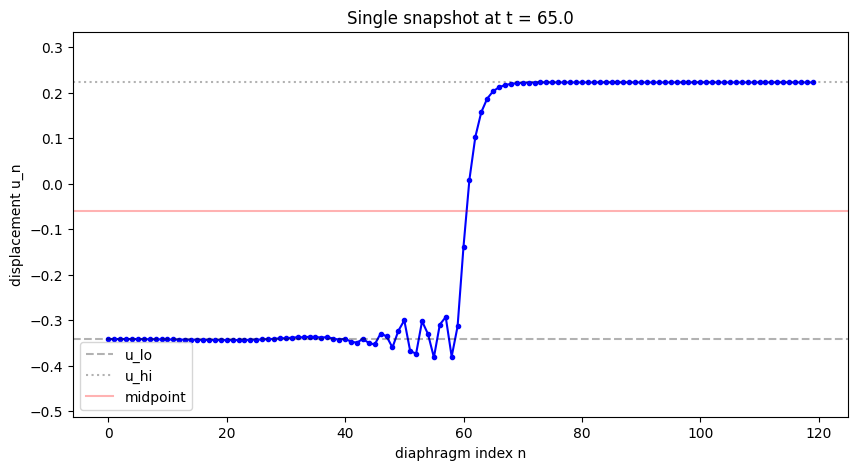

In [5]:
# Single zoomed snapshot to inspect front shape (for fitting w)

idx = len(history) // 2     # pick a snapshot in the steady-state regime
snap = history[idx]
n_array = np.arange(N)

plt.figure(figsize=(10, 5))
plt.plot(n_array, snap, 'b-', marker='o', markersize=3)
plt.axhline(u_lo,                color='k', linestyle='--', alpha=0.3, label='u_lo')
plt.axhline(u_hi,                color='k', linestyle=':',  alpha=0.3, label='u_hi')
plt.axhline(0.5*(u_lo + u_hi),   color='r', linestyle='-',  alpha=0.3, label='midpoint')
plt.xlabel('diaphragm index n')
plt.ylabel('displacement u_n')
plt.title(f'Single snapshot at t = {idx*save_every*dt:.1f}')
plt.ylim(u_lo*1.5, u_hi*1.5)
plt.legend()
plt.show()

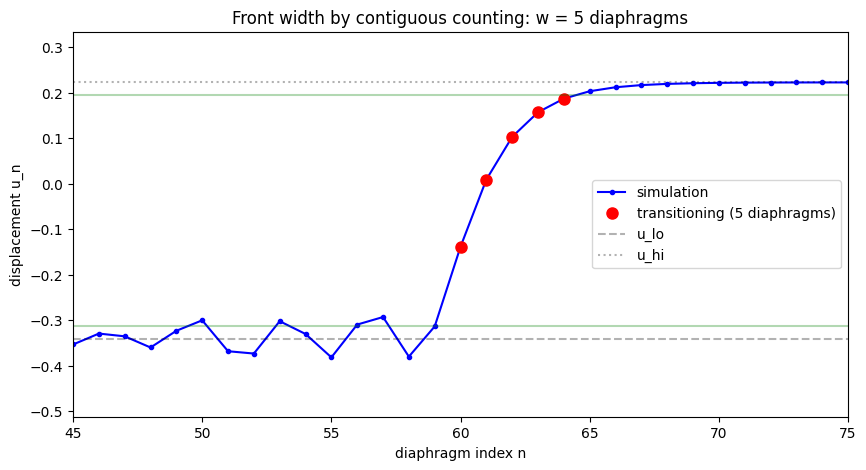

Front centre at n = 60
Front width w = 5 diaphragms
Approximate integral (u_z)^2 = (u_hi - u_lo)^2 / w = 0.0636


In [6]:
# Measure front width w by counting contiguous transitioning diaphragms
# centred on the steepest gradient

# locate the front by maximum gradient
du = np.gradient(snap)
front_centre = int(np.argmax(np.abs(du)))

# expand outward from the front centre while diaphragms are in transition
eps = 0.05 * (u_hi - u_lo)
in_transition = (snap > u_lo + eps) & (snap < u_hi - eps)

# walk left from front centre
left = front_centre
while left > 0 and in_transition[left - 1]:
    left -= 1

# walk right from front centre
right = front_centre
while right < N - 1 and in_transition[right + 1]:
    right += 1

w = right - left + 1   # Inclusive counting
front_indices = np.arange(left, right + 1)

plt.figure(figsize=(10, 5))
plt.plot(n_array, snap, 'b-', marker='o', markersize=3, label='simulation')
plt.plot(n_array[front_indices], snap[front_indices], 'ro', markersize=8,
         label=f'transitioning ({w} diaphragms)')
plt.axhline(u_lo, color='k', linestyle='--', alpha=0.3, label='u_lo')
plt.axhline(u_hi, color='k', linestyle=':',  alpha=0.3, label='u_hi')
plt.axhline(u_lo + eps, color='g', linestyle='-', alpha=0.3)
plt.axhline(u_hi - eps, color='g', linestyle='-', alpha=0.3)
plt.xlabel('diaphragm index n')
plt.ylabel('displacement u_n')
plt.title(f'Front width by contiguous counting: w = {w} diaphragms')
plt.ylim(u_lo*1.5, u_hi*1.5)
plt.xlim(max(0, front_centre - 15), min(N, front_centre + 15))
plt.legend()
plt.show()

print(f'Front centre at n = {front_centre}')
print(f'Front width w = {w} diaphragms')
print(f'Approximate integral (u_z)^2 = (u_hi - u_lo)^2 / w = {(u_hi - u_lo)**2 / w:.4f}')

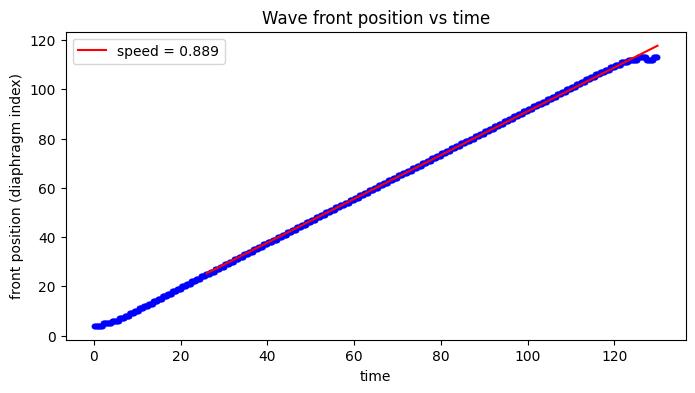

Measured wave speed: 0.8891 sites/time
Energy difference psi(u_hi) - psi(u_lo) = 0.005309


In [7]:
# Wave speed measurement: track front position vs time

mid = 0.5 * (u_lo + u_hi)
front_positions = []
for snap in history:
    front = np.where(snap < mid)[0]
    front_positions.append(front[-1] if len(front) else 0)
front_positions = np.array(front_positions)
times = np.arange(len(history)) * save_every * dt

# fit linear region (skip first 20% as transient)
steady = times > 0.2 * T
if steady.sum() > 5:
    speed, intercept = np.polyfit(times[steady], front_positions[steady], 1)
else:
    speed, intercept = 0.0, 0.0

plt.figure(figsize=(8, 4))
plt.plot(times, front_positions, 'b.', alpha=0.5)
plt.plot(times[steady], speed*times[steady] + intercept, 'r-', label=f'speed = {speed:.3f}')
plt.xlabel("time")
plt.ylabel("front position (diaphragm index)")
plt.title("Wave front position vs time")
plt.legend()
plt.show()

print(f"Measured wave speed: {speed:.4f} sites/time")
print(f"Energy difference psi(u_hi) - psi(u_lo) = {psi(u_hi) - psi(u_lo):.6f}")

In [8]:
# Comparison with formula (13) prediction

#
# Formula (13):  v = [psi(u_hi) - psi(u_lo)] / [gamma * integral((u_z)^2)]
# Approximation: integral((u_z)^2) ~ (u_hi - u_lo)^2 / w
# Damping:       gamma ~ alpha (continuum damping ~ per-site damping at unit lattice spacing)

energy_diff = psi(u_hi) - psi(u_lo)
integral_approx = (u_hi - u_lo)**2 / w
v_predicted = energy_diff / (alpha * integral_approx)

print(f'Energy difference psi(u_hi) - psi(u_lo) = {energy_diff:.6f}')
print(f'Front width w                            = {w}')
print(f'Approximate integral (u_z)^2             = {integral_approx:.4f}')
print(f'Damping gamma ~ alpha                    = {alpha}')
print()
print(f'Predicted wave speed from formula (13)   = {v_predicted:.4f}')
print(f'Measured  wave speed from simulation     = {speed:.4f}')
print(f'Ratio predicted/measured                 = {v_predicted/speed:.2f}')

Energy difference psi(u_hi) - psi(u_lo) = 0.005309
Front width w                            = 5
Approximate integral (u_z)^2             = 0.0636
Damping gamma ~ alpha                    = 0.05

Predicted wave speed from formula (13)   = 1.6700
Measured  wave speed from simulation     = 0.8891
Ratio predicted/measured                 = 1.88


In [9]:
# Direct numerical computation of integral((u_z)^2) from the snapshot
# Compare against the (u_hi - u_lo)^2 / w approximation to see whether the
# discrepancy in v_predicted vs measured speed comes from this approximation.

# discrete derivative (lattice spacing = 1)
du_dn = np.gradient(snap)
integral_direct = np.sum(du_dn**2)

v_predicted_direct = energy_diff / (alpha * integral_direct)

print(f'Integral approximation (u_hi - u_lo)^2 / w   = {integral_approx:.4f}')
print(f'Integral computed directly from snapshot     = {integral_direct:.4f}')
print(f'Ratio direct/approximation                   = {integral_direct/integral_approx:.2f}')
print()
print(f'Predicted v using approximation              = {v_predicted:.4f}')
print(f'Predicted v using direct integral            = {v_predicted_direct:.4f}')
print(f'Measured v from simulation                   = {speed:.4f}')

Integral approximation (u_hi - u_lo)^2 / w   = 0.0636
Integral computed directly from snapshot     = 0.0364
Ratio direct/approximation                   = 0.57

Predicted v using approximation              = 1.6700
Predicted v using direct integral            = 2.9156
Measured v from simulation                   = 0.8891


        dt    Cauchy error   order
   8.0e-04      1.9287e-04      --
   4.0e-04      9.6407e-05    1.00
   2.0e-04      4.8196e-05    1.00
   1.0e-04      2.4096e-05    1.00


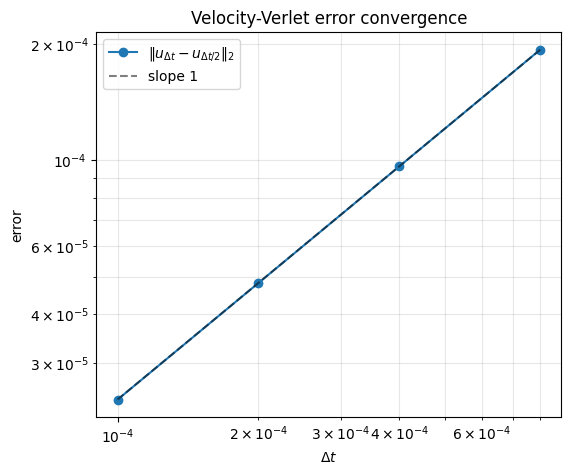

In [11]:
# Error convergence test for the velocity-Verlet scheme
# Cauchy self-convergence: error(dt) = || u_dt(T) - u_{dt/2}(T) ||_2
# Slope on the log-log plot = observed order of accuracy.

def evolve(dt_run, T_run=40.0):
    u = np.ones(N) * u_hi; u[:n_trigger] = u_lo
    v = np.zeros(N); a = acceleration(u, v)
    for _ in range(int(round(T_run / dt_run))):
        u += v * dt_run + 0.5 * a * dt_run**2
        u[:n_trigger] = u_lo; u[-1] = u_hi
        v[:n_trigger] = 0.0;  v[-1] = 0.0
        a_new = acceleration(u, v); v += 0.5 * (a + a_new) * dt_run; a = a_new
    return u

dts    = np.array([8e-4, 4e-4, 2e-4, 1e-4, 5e-5])
sols   = [evolve(d) for d in dts]
errs   = np.array([np.sqrt(np.sum((sols[i] - sols[i+1])**2)) for i in range(len(dts)-1)])
dt_err = dts[:-1]
orders = np.log2(errs[:-1] / errs[1:])

print(f"{'dt':>10}{'Cauchy error':>16}{'order':>8}")
for i in range(len(errs)):
    o = f"{orders[i-1]:.2f}" if i > 0 else "--"
    print(f"{dt_err[i]:10.1e}{errs[i]:16.4e}{o:>8}")

plt.figure(figsize=(6, 5))
plt.loglog(dt_err, errs, 'o-', label=r'$\|u_{\Delta t}-u_{\Delta t/2}\|_2$')
plt.loglog(dt_err, errs[0] / dt_err[0]    * dt_err,     'k--', alpha=0.5, label='slope 1')
plt.xlabel(r'$\Delta t$'); plt.ylabel('error')
plt.title('Velocity-Verlet error convergence')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.show()